In [ ]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
from src.database import get_engine
from sqlalchemy import text
import os
import getpass

os.environ["PGUSER"] = "sgurung"
os.environ["PGDATABASE"] = "citibike"
os.environ["PGPASSWORD"] = getpass.getpass("PostgreSQL password: ")
engine = get_engine()
with engine.connect() as conn:
        data = pd.read_sql(text(
            f"""
            Select *
            from neighborhood_hourly_features
            """
        ), con=conn)

data.head()

,hour,nta_code,nta_name,borough,departures,arrivals,net_flow,temperature,dew_point,precipitation,...,year,month,hour_of_day,day_of_week,is_Holiday,temperature_lag_1hr,precipitation_lag_1hr,snowfall_lag_1hr,arrivals_historical_average,departures_historical_average
0,2025-01-29 07:00:00,BK0101,Greenpoint,Brooklyn,147.0,49.0,-98.0,2.60,-4.35,0.0,...,2025,1,7,2,False,2.65,0.0,0.0,12.00,13.50
1,2025-01-29 08:00:00,BK0101,Greenpoint,Brooklyn,260.0,124.0,-136.0,2.65,-5.75,0.0,...,2025,1,8,2,False,2.60,0.0,0.0,10.75,25.50
2,2025-01-29 09:00:00,BK0101,Greenpoint,Brooklyn,121.0,102.0,-19.0,4.55,-5.25,0.0,...,2025,1,9,2,False,2.65,0.0,0.0,27.50,46.75
3,2025-01-29 10:00:00,BK0101,Greenpoint,Brooklyn,77.0,76.0,-1.0,6.40,-5.00,0.0,...,2025,1,10,2,False,4.55,0.0,0.0,38.00,57.75
4,2025-01-29 11:00:00,BK0101,Greenpoint,Brooklyn,88.0,91.0,3.0,7.85,-2.90,0.0,...,2025,1,11,2,False,6.40,0.0,0.0,47.75,61.25


In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1426536 entries, 0 to 1426535
Data columns (total 23 columns):
 #   Column                         Non-Null Count    Dtype         
---  ------                         --------------    -----         
 0   hour                           1426536 non-null  datetime64[ns]
 1   nta_code                       1426536 non-null  object        
 2   nta_name                       1426536 non-null  object        
 3   borough                        1426536 non-null  object        
 4   departures                     1426536 non-null  float64       
 5   arrivals                       1426536 non-null  float64       
 6   net_flow                       1426536 non-null  float64       
 7   temperature                    1426536 non-null  float64       
 8   dew_point                      1426536 non-null  float64       
 9   precipitation                  1426536 non-null  float64       
 10  snowfall                       1426536 non-null  float

In [42]:
data.columns

Index(['hour', 'nta_code', 'nta_name', 'borough', 'departures', 'arrivals',
       'net_flow', 'temperature', 'dew_point', 'precipitation', 'snowfall',
       'weather_code', 'wind_speed', 'year', 'month', 'hour_of_day',
       'day_of_week', 'is_Holiday', 'temperature_lag_1hr',
       'precipitation_lag_1hr', 'snowfall_lag_1hr',
       'arrivals_historical_average', 'departures_historical_average'],
      dtype='object')

In [43]:
num_features= [
    "year",
    "temperature",
    "dew_point",
    "precipitation",
    "snowfall",
    "wind_speed",
    "temperature_lag_1hr",
    "precipitation_lag_1hr",
    "snowfall_lag_1hr",
    "departures_historical_average",
    "arrivals_historical_average",

]

cat_features =  [
    "nta_code",
    "borough",
    "month",
    "hour_of_day",
    "day_of_week",
    "is_Holiday",
    "weather_code"
]


features = num_features + cat_features

In [44]:
target_cols = ["arrivals", "departures"]

In [45]:
data[cat_features] = data[cat_features].astype("str").astype("category")

In [46]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [47]:
test_start = pd.Timestamp("2026-06-01")
test_end = pd.Timestamp("2026-06-08")

train_data = data.loc[data["hour"]<test_start].copy()
test_data = data.loc[data["hour"]>= test_start].copy()

X_train = train_data[features]
X_test = test_data[features]


In [48]:
models = {}
predictions = {}

for target in target_cols:
    print(f"Training {target} model")
    model = XGBRegressor(
        objective="count:poisson",
        n_estimators=500,
        random_state=67
    )
    model.fit(X_train, train_data[target])

    predictions[target] = model.predict(X_test)

    models[target] = model



Training arrivals model
Training departures model


In [49]:
results = test_data[["hour", "nta_code", "nta_name", "borough","arrivals","departures", "net_flow"]].copy()
results["predicted_arrivals"] = predictions["arrivals"]
results["predicted_departures"] = predictions["departures"]

results["predicted_net_flow"] = (results["predicted_arrivals"] - results["predicted_departures"])


In [51]:
baseline_arrivals = test_data[
    [
    "departures_historical_average",
    "arrivals_historical_average",
    ]
].mean(axis=1).to_numpy()

baseline_departures = test_data[
    [
    "departures_historical_average",
    "arrivals_historical_average",
    ]
].mean(axis=1).to_numpy()

baseline_predictions = {
    "arrivals": baseline_arrivals,
    "departures": baseline_departures,
}

In [52]:
for target in target_cols:
    actual = results[target]
    predicted = results[f"predicted_{target}"]

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual,predicted))

    print(f"{target.title()} \n MAE: {mae:.3f} \n RMSE:{rmse:.3f}")


Arrivals 
 MAE: 12.438 
 RMSE:30.824
Departures 
 MAE: 12.731 
 RMSE:32.500


In [53]:
for target in target_cols:
    actual = results[target]
    predicted = baseline_predictions[target]

    mae = mean_absolute_error(
        actual,
        predicted,
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted,
        )
    )

    print(
        f"Baseline {target.title()}\n"
        f"MAE: {mae:.3f}\n"
        f"RMSE: {rmse:.3f}"
    )
    

Baseline Arrivals
MAE: 17.346
RMSE: 40.774
Baseline Departures
MAE: 17.804
RMSE: 41.650


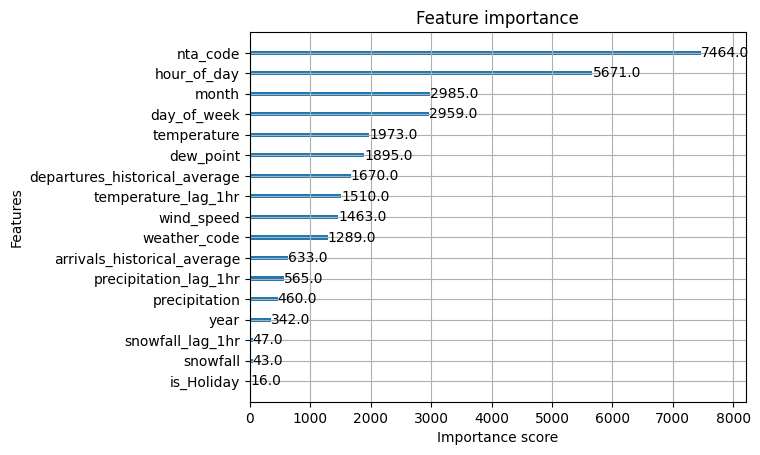

In [54]:
import xgboost as xgb
import matplotlib.pyplot as plt
xgb.plot_importance(model)
plt.show()